# RPS Classification에 QAT 적용

## 설명 노트

각 코드 셀에 주석을 추가한 버전입니다.

- 인식 대상: 가위(scissors), 바위(rock), 보(paper)
- 사용 모델: `DenseNet121`
- 입력 크기: `64 x 64 x 3` 컬러 이미지
- 핵심 기법: 데이터 보강(Augmentation) + QAT(Quantization Aware Training) + TFLite 변환
- 최종 산출물: `RPS_PreTrained_DenseNet_Augmentation_QAT.tflite`

라즈베리파이에서는 최종 `.tflite` 파일을 사용해 카메라 손 모양을 가위/바위/보로 분류할 수 있습니다.


## Install TensorFlow Model Optimization Toolkit
* 설치 완료 후 반드시 Runtime 재시작!
    * '런타임' > '세션 다시 시작' 메뉴 선택'

In [1]:
# 필요한 패키지 설치
# Colab, GCP GPU 서버, VSCode Jupyter 모두에서 실행할 수 있게 작성했습니다.
#
# tensorflow-model-optimization: QAT 적용용
# opencv-python-headless: 서버 환경에서 이미지 읽기용. GUI 창이 필요 없으므로 headless 버전을 권장합니다.
# scikit-learn: train/test split용

import sys
import subprocess

required_packages = [
    "tensorflow-model-optimization",
    "opencv-python-headless",
    "scikit-learn",
]

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    *required_packages
], check=True)

print("Package installation/check complete.")


Package installation/check complete.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 모듈 로딩

In [2]:
# [GPU 설정] TensorFlow import 전에 실행되어야 함 (기존 코드와 별개로 추가됨)
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"      # GPU 1번만 사용
os.environ["MKL_THREADING_LAYER"] = "GNU"     # MKL <-> OpenMP 충돌(커널 크래시) 방지

In [3]:
# 기본 라이브러리 불러오기
# numpy: 배열 계산
# tensorflow/keras: 딥러닝 모델 생성과 학습
# matplotlib: 결과 그래프와 이미지 확인
# glob: 폴더 안 파일 목록 읽기
# cv2(OpenCV): 이미지 읽기, 색상 변환, 크기 변경
# train_test_split: 학습용/테스트용 데이터 분리
# tfmot: TensorFlow 모델 경량화와 QAT 적용
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.keras.compat import keras

# 현재 실행 환경의 주요 라이브러리 버전을 확인합니다.
# 버전 차이 때문에 QAT API가 다르게 동작할 수 있어 처음에 확인하는 것이 좋습니다.
print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))


I0000 00:00:1780893059.503425  597840 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780893059.611760  597840 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780893070.582262  597840 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


NumPy Version :2.2.4
TensorFlow Version :2.21.0
Matplotlib Version :3.10.9


In [4]:
# [GPU 확인] 비어 있으면 CPU로 도는 중
gpus = tf.config.list_physical_devices("GPU")
print("사용 가능한 GPU:", gpus)
print("GPU 사용" if gpus else "GPU 미인식 -> CPU 사용 중")

사용 가능한 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU 사용


### 실행 환경 확인

이 학생용 저장소는 `RPS_Dataset` 폴더를 저장소 안에 포함합니다.
따라서 Google Drive를 연결하지 않아도 Colab, GCP GPU 서버, VSCode에서 같은 방식으로 실행할 수 있습니다.


In [5]:
# Colab인지, GCP/VSCode 같은 일반 Python 환경인지 확인합니다.
# 데이터셋은 다음 셀에서 저장소 내부의 RPS_Dataset 폴더를 자동으로 찾습니다.
try:
    import google.colab  # type: ignore
    colab = True
    print("Colab environment.")
except Exception:
    colab = False
    print("Local/GCP/VSCode environment.")


Local/GCP/VSCode environment.


### RPS 데이터셋 준비

In [6]:
from pathlib import Path
# # RPS 데이터셋 경로 설정
# # 이 학생용 저장소는 구조가 단순합니다.
# #
# # RP2-RPS-QAT-Lab/
# #   RPS_Dataset/
# #   notebooks/
# #
# # 따라서 학생이 이 저장소를 fork/clone했다면 별도 다운로드 없이 RPS_Dataset을 바로 사용합니다.

# import subprocess
# from pathlib import Path

# # 데이터셋이 포함된 학생용 실습 저장소입니다.
# # 자기 fork 저장소를 자동 clone 대상으로 쓰고 싶으면 아래 URL만 바꾸면 됩니다.
# # 예: "https://github.com/학생아이디/RP2-RPS-QAT-Lab.git"
# GITHUB_REPO_URL = "https://github.com/philipdekim-OnD01/RP2-RPS-QAT-Lab.git"

# COLAB_REPO_DIR = Path("/content/RP2-RPS-QAT-Lab")
# SERVER_REPO_DIR = Path.home() / "RP2-RPS-QAT-Lab_data"


# def get_git_root():
#     """현재 노트북이 Git 저장소 안에서 실행 중이면 저장소 루트 경로를 반환합니다."""
#     try:
#         result = subprocess.run(
#             ["git", "rev-parse", "--show-toplevel"],
#             check=True,
#             capture_output=True,
#             text=True,
#         )
#         return Path(result.stdout.strip())
#     except Exception:
#         return None


# def clone_repo_if_needed(target_dir):
#     """데이터셋이 없을 때 학생용 GitHub 저장소를 clone합니다."""
#     if not target_dir.exists():
#         print("Clone GitHub repository for RPS_Dataset:", GITHUB_REPO_URL)
#         subprocess.run([
#             "git", "clone", "--depth", "1",
#             GITHUB_REPO_URL,
#             str(target_dir)
#         ], check=True)
#     else:
#         print("Repository already exists:", target_dir)
#     return target_dir


# candidate_paths = []

# # 1) VSCode에서 fork 저장소 폴더를 열고 실행하면 이 경로가 가장 안정적입니다.
# git_root = get_git_root()
# if git_root is not None:
#     candidate_paths.append(git_root / "RPS_Dataset")

# # 2) 노트북 실행 위치가 notebooks/이거나 저장소 루트일 때 가능한 경로들입니다.
# cwd = Path.cwd()
# candidate_paths.extend([
#     cwd / "RPS_Dataset",
#     cwd / "../RPS_Dataset",
#     Path("RPS_Dataset"),
#     Path("../RPS_Dataset"),
# ])

# files_path = None
# for candidate in candidate_paths:
#     candidate = candidate.resolve()
#     if candidate.exists() and candidate.is_dir():
#         files_path = str(candidate)
#         break

# # 3) 그래도 못 찾으면 GitHub에서 학생용 저장소를 clone해서 데이터를 준비합니다.
# if files_path is None:
#     clone_dir = COLAB_REPO_DIR if colab else SERVER_REPO_DIR
#     repo_dir = clone_repo_if_needed(clone_dir)
#     dataset_dir = repo_dir / "RPS_Dataset"
#     if not dataset_dir.exists():
#         raise FileNotFoundError(
#             f"RPS_Dataset 폴더를 찾을 수 없습니다: {dataset_dir}. "
#             "GITHUB_REPO_URL이 올바른지 확인하세요."
#         )
#     files_path = str(dataset_dir)

# print("Working directory:", Path.cwd())
# print("Git root:", git_root)
files_path = "RPS_Dataset"
print("RPS dataset path:", files_path)
print("Class folders:", sorted([p.name for p in Path(files_path).iterdir() if p.is_dir()]))

# 폴더 구조
# RPS_Dataset/
#   0/  -> scissors, 가위
#   1/  -> rock, 바위
#   2/  -> paper, 보


RPS dataset path: RPS_Dataset
Class folders: ['0', '1', '2']


### 폴더 별로 파일 읽어 데이터화 진행

In [7]:
%%time
# 이미지 파일을 읽어서 모델 학습에 사용할 numpy 배열로 만드는 단계입니다.
# 최종 모델 입력 크기는 64 x 64 x 3 입니다.
# 64 x 64: 이미지 크기
# 3: RGB 컬러 채널

first = True
IMG_SIZE = 64

# ind는 클래스 번호입니다.
# 0: scissors, 1: rock, 2: paper
for ind in range(0, 3, 1) :
    # 각 클래스 폴더 안의 모든 이미지 파일을 읽습니다.
    path = files_path + '/' + str(ind) + '/*.*'
    print(path)
    files = glob.glob(path)

    # 이미지 처리 흐름
    # 1) cv2.imread(): 이미지 파일 읽기. OpenCV는 BGR 순서로 읽습니다.
    # 2) cv2.cvtColor(..., COLOR_BGR2RGB): BGR을 RGB로 바꿉니다.
    # 3) cv2.resize(): 모든 이미지를 64 x 64로 맞춥니다.
    # 4) np.array(): 여러 장의 이미지를 하나의 배열로 묶습니다.
    tmpx = np.array([
        cv2.resize(
            cv2.cvtColor(cv2.imread(x, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB),
            (IMG_SIZE, IMG_SIZE)
        )
        for x in files
    ])

    # tmpy는 정답 라벨입니다.
    # 현재 폴더 번호 ind를 이미지 개수만큼 반복해서 라벨 배열을 만듭니다.
    tmpy = np.array([ind] * len(files))

    # 각 클래스별로 80%는 학습용, 20%는 테스트용으로 나눕니다.
    # random_state를 고정하면 매번 같은 방식으로 나뉘어 실험 결과 비교가 쉽습니다.
    xtrain, xtest, ytrain, ytest = train_test_split(
        tmpx, tmpy, test_size=0.2, random_state=123
    )

    # 첫 클래스는 배열을 새로 만들고,
    # 두 번째 클래스부터는 기존 배열 뒤에 이어 붙입니다.
    if first == True:
        train_data = xtrain.copy()
        train_labels = ytrain.copy()
        test_data = xtest.copy()
        test_labels = ytest.copy()
        first = False
    else :
        train_data = np.concatenate((train_data, xtrain))
        train_labels = np.concatenate((train_labels, ytrain))
        test_data = np.concatenate((test_data, xtest))
        test_labels = np.concatenate((test_labels, ytest))


RPS_Dataset/0/*.*
RPS_Dataset/1/*.*
RPS_Dataset/2/*.*
CPU times: user 20.9 s, sys: 575 ms, total: 21.5 s
Wall time: 26.7 s


### 데이터 확인

In [8]:
# 데이터 모양(shape)을 확인합니다.
# 예상 형태:
# train_data   -> (학습 이미지 수, 64, 64, 3)
# train_labels -> (학습 라벨 수,)
# test_data    -> (테스트 이미지 수, 64, 64, 3)
# test_labels  -> (테스트 라벨 수,)

# DenseNet의 preprocess_input()에서 입력 전처리를 처리합니다.
# 그래서 여기서는 train_data / 255.0 같은 정규화를 하지 않습니다.
# train_data = train_data / 255.0
# test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)


(2172, 64, 64, 3)
(2172,)
(545, 64, 64, 3)
(545,)


### ImageDataGenerator 객체 생성

In [9]:
# ImageDataGenerator는 학습 이미지를 매번 조금씩 변형해 주는 도구입니다.
# 목적: 실제 카메라 환경처럼 손 위치, 밝기, 각도, 크기가 달라져도 잘 맞히게 만들기
img_gen_train = tf.keras.preprocessing.image.ImageDataGenerator(
                horizontal_flip=True,         # 좌우 반전. 손 모양 방향이 바뀌는 상황 대응
                rotation_range=0.2,           # 이미지를 조금 회전. 손이 기울어진 상황 대응
                width_shift_range=0.1,        # 좌우 이동. 손이 중앙에서 벗어난 상황 대응
                height_shift_range=0.1,       # 상하 이동. 손 높이가 달라지는 상황 대응
                brightness_range=(0.1, 0.9),  # 밝기 변화. 조명이 어둡거나 밝은 상황 대응
                zoom_range=0.2                # 확대/축소. 카메라와 손 거리 변화 대응
                )

# flow()는 원본 train_data를 읽어, 학습 중에 변형된 이미지를 계속 공급합니다.
# seed를 고정하면 실험 재현성이 좋아집니다.
train_gen = img_gen_train.flow(train_data, train_labels, seed = 1)


### 모델 생성


In [10]:
# 모델 생성 단계
# 이 코드는 ResNet이 아니라 DenseNet121을 사용합니다.
# DenseNet121은 ImageNet으로 미리 학습된 이미지 인식 모델입니다.
# 우리는 맨 뒤 분류기를 가위/바위/보 3개 클래스로 바꿔서 사용합니다.

# 입력 이미지는 64 x 64 RGB 이미지입니다.
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# DenseNet이 기대하는 방식으로 입력 이미지를 전처리합니다.
# 픽셀 스케일과 색상 기준을 DenseNet 학습 방식에 맞춥니다.
x = keras.applications.densenet.preprocess_input(inputs)

# ImageNet 사전학습 가중치를 가진 DenseNet121을 불러옵니다.
# include_top=False는 ImageNet용 1000개 클래스 분류 머리를 제거한다는 뜻입니다.
# input_tensor=x로 우리가 만든 입력과 전처리 흐름을 연결합니다.
base_model = keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_tensor = x
)

# BatchNormalization layer는 학습 중 통계가 흔들리면 전이학습 성능이 불안정할 수 있어 고정합니다.
# 나머지 layer는 trainable=True로 두어 RPS 데이터에 맞게 미세조정합니다.
for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

# DenseNet이 뽑은 특징맵을 하나의 벡터로 요약합니다.
x = base_model.output
x = keras.layers.GlobalAveragePooling2D()(x)

# Dropout은 과적합을 줄이기 위해 일부 뉴런을 학습 중 임의로 꺼 줍니다.
x = keras.layers.Dropout(0.2)(x)

# 최종 출력은 3개입니다.
# 0: scissors, 1: rock, 2: paper
outputs = keras.layers.Dense(3, activation='softmax')(x)

# 입력부터 출력까지 연결한 최종 모델입니다.
model = keras.Model(inputs, outputs)

# 모델 구조와 파라미터 수를 확인합니다.
model.summary()


I0000 00:00:1780893125.254492  597840 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22290 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:3d:00.0, compute capability: 8.9


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 tf.math.truediv (TFOpLambd  (None, 64, 64, 3)            0         ['input_1[0][0]']             
 a)                                                                                               
                                                                                                  
 tf.nn.bias_add (TFOpLambda  (None, 64, 64, 3)            0         ['tf.math.truediv[0][0]']     
 )                                                                                                
                                                                                              

In [11]:
# QAT(Quantization Aware Training) 적용 준비
# QAT는 나중에 TFLite 양자화 모델로 바꿀 때 정확도 손실을 줄이기 위한 학습 방법입니다.
# 학습 중에 int8 양자화로 생길 오차를 미리 흉내 내면서 모델을 적응시킵니다.

# 선택적 양자화 함수
# 모든 layer를 양자화하지 않고, 주로 계산량이 큰 Dense와 Conv2D layer에만 표시합니다.
def apply_quantization_to_layer(layer):
    # Dense와 Conv2D 레이어만 양자화 대상이라고 표시합니다.
    if isinstance(layer, (keras.layers.Dense, keras.layers.Conv2D)):
        return tfmot.quantization.keras.quantize_annotate_layer(layer)

    # 나머지 layer는 그대로 둡니다.
    return layer

# 기존 model을 복제하면서 위 함수가 지정한 layer에 양자화 annotation을 붙입니다.
annotated_model = keras.models.clone_model(
    model,
    clone_function=apply_quantization_to_layer,
)

# annotation을 실제 QAT layer로 변환합니다.
# 이 결과가 학습에 사용할 qat_model입니다.
qat_model = tfmot.quantization.keras.quantize_apply(annotated_model)


In [12]:
# QAT가 적용된 모델 구조를 확인합니다.
# Conv2D나 Dense layer 주변에 QuantizeWrapperV2가 보이면 QAT 적용이 된 것입니다.
qat_model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 tf.math.truediv (TFOpLambd  (None, 64, 64, 3)            0         ['input_1[0][0]']             
 a)                                                                                               
                                                                                                  
 tf.nn.bias_add (TFOpLambda  (None, 64, 64, 3)            0         ['tf.math.truediv[1][0]']     
 )                                                                                                
                                                                                              

### 모델 컴파일

In [13]:
# 모델 학습 설정
# optimizer: Adam 사용
# learning_rate=1e-5: 사전학습 모델을 미세조정하므로 학습률을 작게 둡니다.
# loss: sparse_categorical_crossentropy
#   라벨이 one-hot이 아니라 0, 1, 2 정수이기 때문에 sparse 버전을 사용합니다.
# metrics: accuracy로 정확도를 확인합니다.
qat_model.compile(optimizer= keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


### 학습 전 상황

In [14]:
# 예측 결과를 눈으로 확인하기 위한 함수입니다.
# 테스트 이미지 10장을 골라 실제 라벨과 모델 예측값을 제목에 표시합니다.
def Make_Result_Plot(suptitle, data, label, y_max):
    # 테스트 데이터를 10개 구간으로 나누어 대표 이미지를 하나씩 봅니다.
    size = data.shape[0]//10

    # 2행 5열 그림판을 만듭니다.
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)

    for idx in range(10):
        cnt = idx * size + size//2

        # 이미지 출력
        ax_result[idx//5,idx%5].imshow(data[cnt].reshape((IMG_SIZE,IMG_SIZE, 3)))

        # label: 실제 정답, y: 모델 예측값
        ax_result[idx//5,idx%5].set_title(
            "test_data[{}] (label : {} / y : {})".format(cnt, label[cnt], y_max[cnt])
        )


I0000 00:00:1780893157.794446  612581 cuda_dnn.cc:461] Loaded cuDNN version 92300


18/18 [==============================] - 7s 168ms/step


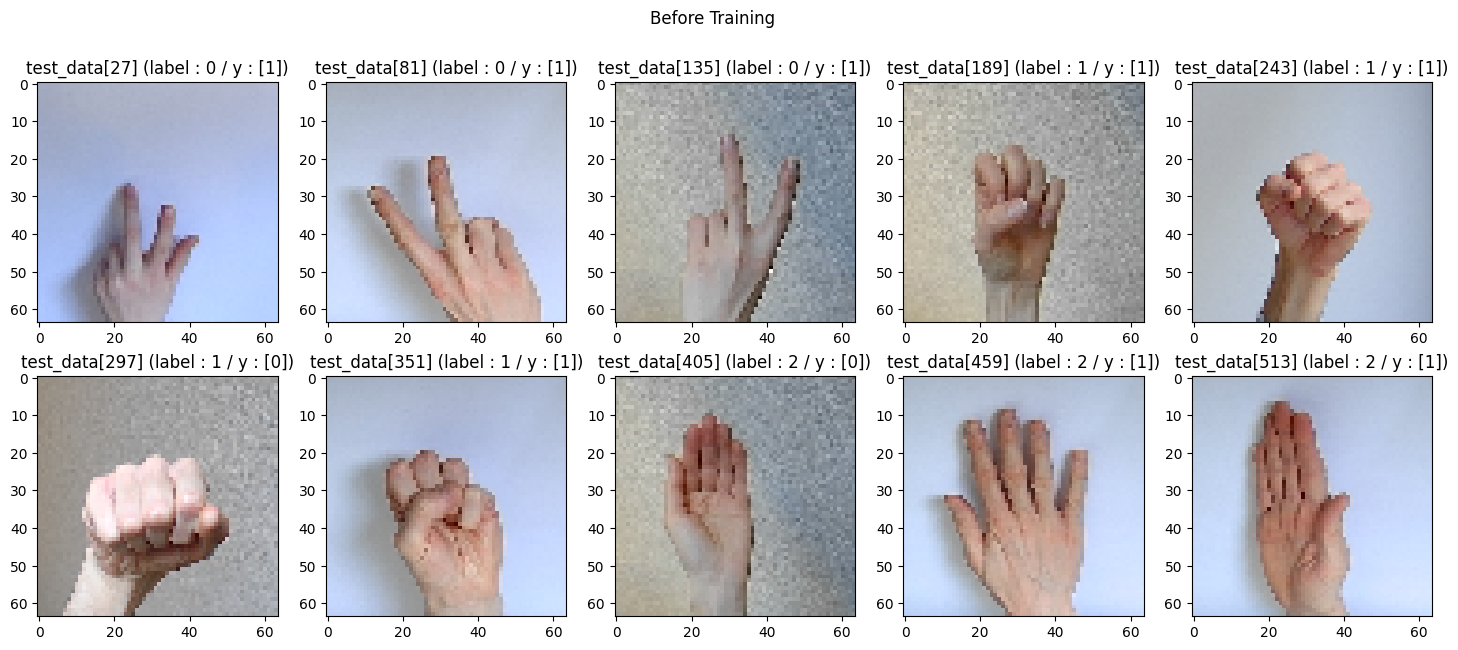

In [15]:
# 학습 전 모델의 예측 상태를 확인합니다.
# 아직 RPS 데이터에 맞게 충분히 학습되지 않았기 때문에 틀리는 예측이 많을 수 있습니다.
y_out = qat_model.predict(test_data)

# softmax 출력 3개 중 가장 큰 값의 위치를 예측 클래스로 선택합니다.
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))

# 학습 전 예측 결과를 그림으로 확인합니다.
Make_Result_Plot("Before Training", test_data, test_labels, y_max)


### 콜백 설정

In [16]:
# 학습 중 가장 성능이 좋은 모델을 저장하기 위한 설정입니다.
# h5 파일에는 QAT가 적용된 Keras 모델이 저장됩니다.
savedModelName = 'RPS_PreTrained_DenseNet_Augmentation_QAT.h5'

callbacks = [
    # save_best_only=True: 검증 성능이 가장 좋을 때만 저장합니다.
    keras.callbacks.ModelCheckpoint(savedModelName,
                                    save_best_only=True)
]


### 모델 학습

In [17]:
%%time
# 모델 학습
# train_gen은 ImageDataGenerator가 만든 변형 이미지를 계속 공급합니다.
# epochs=10은 전체 학습 데이터를 10번 반복해서 본다는 뜻입니다.
# validation_data는 학습에 쓰지 않은 test_data로 성능을 확인합니다.
history = qat_model.fit(train_gen, epochs=10,
                    callbacks=callbacks,
                    validation_data=(test_data, test_labels))


Epoch 1/10


I0000 00:00:1780893162.868533  597840 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1780893189.326319  612547 service.cc:153] XLA service 0x7fd574040460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780893189.326362  612547 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780893189.335164  612547 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780893189.563887  612547 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/68 [==============================] - ETA: 0s - loss: 1.2417 - accuracy: 0.4977

/hai/home/sjm/.conda/envs/fpga-py-env/lib/python3.10/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


68/68 [==============================] - 100s 637ms/step - loss: 1.2417 - accuracy: 0.4977 - val_loss: 0.5499 - val_accuracy: 0.7963
Epoch 2/10
68/68 [==============================] - 38s 558ms/step - loss: 0.5806 - accuracy: 0.7472 - val_loss: 0.2953 - val_accuracy: 0.9009
Epoch 3/10
68/68 [==============================] - 38s 556ms/step - loss: 0.3204 - accuracy: 0.8757 - val_loss: 0.1398 - val_accuracy: 0.9541
Epoch 4/10
68/68 [==============================] - 39s 570ms/step - loss: 0.2163 - accuracy: 0.9213 - val_loss: 0.1298 - val_accuracy: 0.9523
Epoch 5/10
68/68 [==============================] - 35s 510ms/step - loss: 0.1494 - accuracy: 0.9461 - val_loss: 0.1168 - val_accuracy: 0.9615
Epoch 6/10
68/68 [==============================] - 38s 559ms/step - loss: 0.1092 - accuracy: 0.9595 - val_loss: 0.0928 - val_accuracy: 0.9706
Epoch 7/10
68/68 [==============================] - 36s 531ms/step - loss: 0.0848 - accuracy: 0.9719 - val_loss: 0.0521 - val_accuracy: 0.9798
Epoch 8/1

> ### Ploting : Cost/Training Count

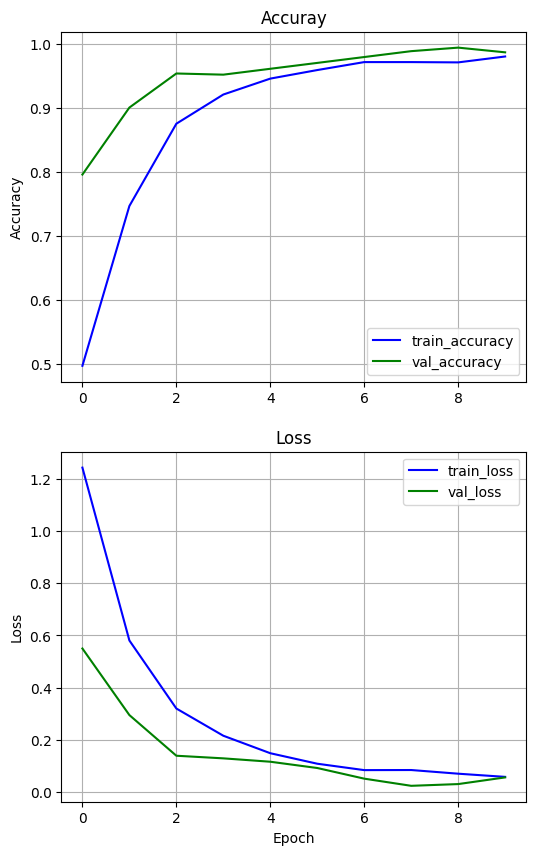

In [18]:
# 학습 과정 시각화
# 위 그래프: 정확도 변화
# 아래 그래프: 손실(loss) 변화
# train과 validation이 함께 좋아지면 학습이 잘 되고 있는 것입니다.

plt.figure(figsize=(6, 10))

# 정확도 그래프
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(history.history['val_accuracy'], 'g', label='val_accuracy')
# plt.ylim([0,1])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

# 손실 그래프
plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(history.history['loss'], 'b', label='train_loss')
plt.plot(history.history['val_loss'], 'g', label='val_loss')
# plt.ylim([0,5])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()


### best 모델 로딩 및 테스트

In [19]:
# 저장된 best 모델 다시 불러오기
# QAT 모델에는 QuantizeWrapperV2 같은 특수 layer가 들어 있습니다.
# 그래서 일반 load_model이 아니라 quantize_scope 안에서 불러와야 합니다.
from tensorflow_model_optimization.quantization.keras import quantize_scope

try:
    # quantize_scope() 안에서 모델을 로드하면 QAT 관련 사용자 정의 객체를 인식합니다.
    with quantize_scope():
        model_best = keras.models.load_model(savedModelName)
except ValueError as e:
    print(f"Model load failed: {e}")


18/18 [==============================] - 7s 176ms/step


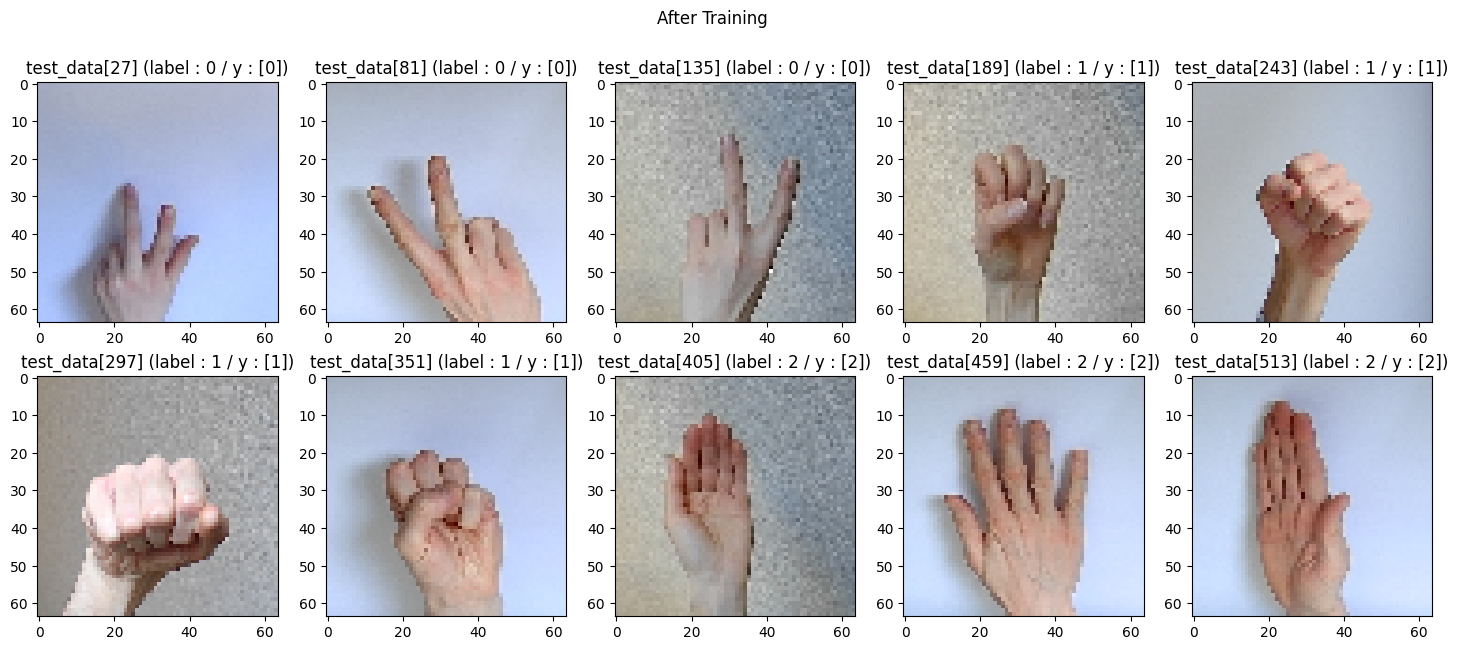

In [20]:
# 학습 후 best 모델의 예측 결과를 확인합니다.
y_out = model_best.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)


### best 모델 백업

In [21]:
# 학습된 모델과 TFLite 파일을 저장할 위치를 정합니다.
# 학생용 저장소에서는 results/ 폴더에 결과를 저장합니다.
# results/는 .gitignore에 들어 있으므로 큰 모델 파일이 실수로 push되지 않습니다.
from pathlib import Path

try:
    repo_root = get_git_root()
except NameError:
    repo_root = None

if repo_root is None:
    repo_root = Path.cwd()

save_dir = str(repo_root / "results") + "/"
Path(save_dir).mkdir(parents=True, exist_ok=True)
print("save_dir:", save_dir)


save_dir: /hai/home/sjm/sys5284/week15/results/


In [22]:
# 학습된 best Keras 모델(.h5)을 results/ 폴더로 복사합니다.
# results/는 .gitignore에 포함되어 있어 GitHub에는 올라가지 않습니다.
import shutil
from pathlib import Path

src_model = Path(savedModelName)
dst_model = Path(save_dir) / savedModelName

if src_model.exists():
    shutil.copy2(src_model, dst_model)
    print("Saved best model to:", dst_model)
else:
    print("Model file not found:", src_model)


Saved best model to: /hai/home/sjm/sys5284/week15/results/RPS_PreTrained_DenseNet_Augmentation_QAT.h5


### 초보자 핵심 정리

여기까지의 핵심은 다음과 같습니다.

1. `RPS_Dataset`에서 가위/바위/보 이미지를 읽어 `64 x 64 x 3` 배열로 만듭니다.
2. ImageNet으로 미리 학습된 `DenseNet121`을 가져와 마지막 분류기를 3개 클래스로 바꿉니다.
3. 데이터 보강으로 조명, 위치, 회전, 크기 변화에 강하게 만듭니다.
4. QAT를 적용해 TFLite 양자화 후에도 정확도가 유지되도록 학습합니다.
5. 최종 `.tflite` 파일을 라즈베리파이에 복사해 실시간 손 모양 인식에 사용합니다.


### LiteRT 모델로 변환

In [23]:
# Keras QAT 모델을 TFLite 모델로 변환합니다.
# TFLite는 라즈베리파이 같은 엣지 장치에서 실행하기 좋은 모델 형식입니다.
converter = tf.lite.TFLiteConverter.from_keras_model(model_best)

# Optimize.DEFAULT는 기본 양자화/최적화를 적용하라는 뜻입니다.
# QAT로 학습했기 때문에 양자화 후 정확도 손실을 줄이는 데 도움이 됩니다.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 실제 변환 실행. 결과는 bytes 형태의 tflite_model입니다.
tflite_model = converter.convert()


INFO:tensorflow:Assets written to: /tmp/tmpuil5uc8q/assets


INFO:tensorflow:Assets written to: /tmp/tmpuil5uc8q/assets
/hai/home/sjm/.conda/envs/fpga-py-env/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1780893746.147223  597840 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780893746.147443  597840 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780893746.148595  597840 reader.cc:83] Reading SavedModel from: /tmp/tmpuil5uc8q
I0000 00:00:1780893746.302674  597840 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780893746.302928  597840 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpuil5uc8q
I0000 00:00:1780893747.154387  597840 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1780893747.381901  597840 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:178089

### LiteRT 모델을 파일로 저장

In [24]:
# 라즈베리파이에 가져갈 최종 TFLite 파일 이름입니다.
# 이 파일을 Raspberry Pi에서 tflite_runtime 또는 LiteRT로 실행합니다.
tfliteFileName = 'RPS_PreTrained_DenseNet_Augmentation_QAT.tflite'


In [25]:
# 변환된 TFLite 모델을 파일로 저장합니다.
# 저장 결과가 약 7.7MB 정도라면 정상적으로 만들어진 것입니다.
open(save_dir + tfliteFileName, 'wb').write(tflite_model)


7720736

### 양자화 전후 정확도(accuracy) 비교

- **Float(QAT keras)** 모델과 **INT8 TFLite** 모델을 같은 test set으로 평가해 양자화로 인한 정확도 변화를 정량 측정합니다.
- 사전 실행 필요: model_best(QAT 모델), tflite_model(변환된 INT8 바이트), test_data/test_labels.

In [ ]:
# ===== 양자화 전후 accuracy 비교 =====
import numpy as np

# (1) Float (QAT keras) 모델 정확도
y_float = np.argmax(model_best.predict(test_data, verbose=0), axis=1)
float_acc = float(np.mean(y_float == test_labels))

# (2) INT8 TFLite 모델 정확도
interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
inp = interp.get_input_details()[0]
out = interp.get_output_details()[0]

correct = 0
for img, label in zip(test_data, test_labels):
    x = img[None].astype(np.float32)
    if inp['dtype'] in (np.int8, np.uint8):          # 완전 정수 모델이면 입력도 양자화
        scale, zp = inp['quantization']
        x = (x / scale + zp).astype(inp['dtype'])
    interp.set_tensor(inp['index'], x)
    interp.invoke()
    if np.argmax(interp.get_tensor(out['index'])[0]) == label:
        correct += 1
int8_acc = correct / len(test_data)

print('=' * 45)
print(f"Float(QAT) accuracy : {float_acc:.4f}")
print(f"INT8 TFLite accuracy: {int8_acc:.4f}")
print(f"정확도 변화         : {(int8_acc - float_acc) * 100:+.2f} %p")
print('=' * 45)